In [1]:
# Import TensorFlow for building, training, and evaluating the neural network.
# Matplotlib is used to visualize sample images from the dataset.
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
# Load the Fashion-MNIST dataset and divide it into training and testing sets.
# The training set is used to learn the model parameters, while the test set
# is used to evaluate how well the trained model performs on unseen images.
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Normalize pixel values from the range [0, 255] to [0, 1].
# This helps the neural network train more efficiently and improves numerical stability.
train_images = train_images / 255.0
test_images = test_images / 255.0

In [4]:
# Inspect the dimensions of the training and testing datasets
# and display the corresponding training labels.
print("Training Images:", train_images.shape)
print("Testing Images:", test_images.shape)
print("First 10 Training Labels:", train_labels[:10])

Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)
First 10 Training Labels: [9 0 0 3 0 2 7 2 5 5]


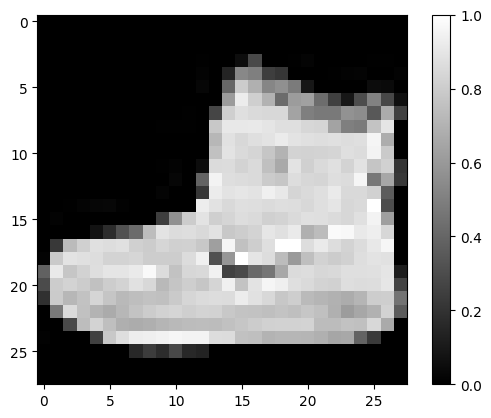

In [5]:
# Visualize the first image in the training dataset.
# The color bar represents the normalized pixel intensity values.
plt.imshow(train_images[0], cmap='gray')
plt.colorbar()
plt.show()

In [6]:
# Define the class names corresponding to the numerical labels (0–9)
# in the Fashion-MNIST dataset.
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

print(class_names[train_labels[0]])

Ankle Boot


In [7]:
# Build a Sequential neural network for Fashion-MNIST classification.
# The model processes each 28x28 grayscale image and predicts one of 10 classes.
model = tf.keras.models.Sequential()

# Flatten the 28x28 image into a one-dimensional vector of 784 values.
model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))

# Fully connected hidden layer with 128 neurons.
# ReLU activation introduces non-linearity and helps the network learn complex patterns.
model.add(tf.keras.layers.Dense(128, activation='relu'))

# Output layer with 10 neurons, one for each Fashion-MNIST class.
# Softmax converts the outputs into class probabilities.
model.add(tf.keras.layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
# Configure the model for training.
# Adam is used as the optimizer, while sparse categorical crossentropy
# is suitable because the class labels are represented as integers.
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
# Train the neural network using the training images and their corresponding labels.
# The model will pass through the complete training dataset 5 times (epochs).
model.fit(
    train_images,
    train_labels,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8225 - loss: 0.5002
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8648 - loss: 0.3733
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8781 - loss: 0.3358
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8853 - loss: 0.3120
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8916 - loss: 0.2928


In [10]:
# Evaluate the trained model on the unseen test dataset.
# This measures how well the model generalizes to images it did not see during training.
loss, accuracy = model.evaluate(test_images, test_labels)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8749 - loss: 0.3536
Test Accuracy: 0.8748999834060669


In [11]:
# Generate class-probability predictions for all test images.
predictions = model.predict(test_images)

# Display the predicted probabilities for the first test image.
print(predictions[0])

# Select the class with the highest predicted probability.
predicted_class = predictions[0].argmax()

print("Predicted:", class_names[predicted_class])
print("Actual:", class_names[test_labels[0]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[2.4139604e-06 3.2364461e-08 1.9601181e-07 8.3558206e-08 5.2832121e-07
 1.0053720e-02 5.3218719e-07 4.5759822e-03 2.7587519e-06 9.8536378e-01]
Predicted: Ankle Boot
Actual: Ankle Boot


In [12]:
# Save the trained model so that it can be reused later
# without having to train it again from scratch.
model.save("fashion_mnist_model.keras")

In [13]:
# Display the architecture of the neural network,
# including the layers, output shapes, and number of parameters.
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,542 (795.09 KB)